In [1]:
from datatopic.RenderTopic import RenderData
from renderer.render import *
from matplotlib import pyplot as plt
import random

## Parameter Setting

In [2]:
scene_name = "office0"
scene_path = "sample_scene/replica/" + scene_name + "/"
target_width = 1200
target_height = 680
focal_length_x = 600
focal_length_y = 600
center_x = 599.5
center_y = 339.5

## Render Scene from VR-Map

[INFO]root line 40 : Loading data from sample_scene/replica/office0/, with W=300, H=170, fx=150.000000, fy=150.000000, cx=149.875000, cy=84.875000
[INFO]root line 29 : Loading SRResNet from ./super_resolution/checkpoints/checkpoint_srresnet_voxel_x4_office0_300x170.pth.tar
[WARNING]matplotlib.image line 701 : Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


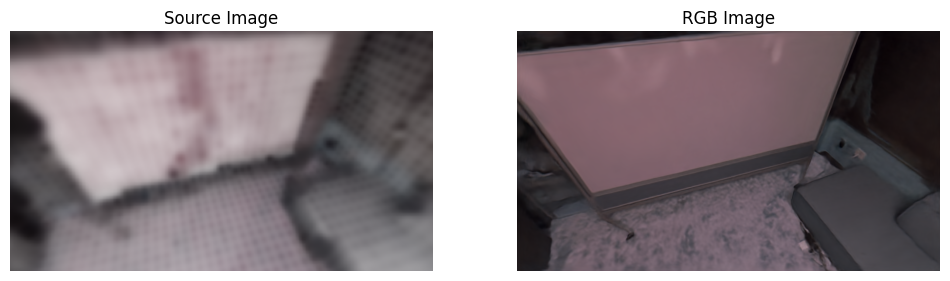

In [3]:
renderer = CRender()
renderer.Control(eRender.DATA_PATH, scene_path)
renderer.Control(eRender.DATA, scene_name)
renderer.Control(eRender.WIDTH, target_width/4)
renderer.Control(eRender.HEIGHT, target_height/4)
renderer.Control(eRender.FOCAL_X, focal_length_x/4)
renderer.Control(eRender.FOCAL_Y, focal_length_y/4)
renderer.Control(eRender.CENTER_X, center_x/4)
renderer.Control(eRender.CENTER_Y, center_y/4)
renderer.Open()
scene_poses = renderer.GetPoses()

render_data = RenderData()
render_data.PoseMatrix = scene_poses[random.randint(0, len(scene_poses)-1)]
renderer.Read(render_data)

rgb_image = render_data.RgbImg / 255.0
src_image = render_data.SrcImg

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(src_image)
axes[0].set_title('Source Image')
axes[0].axis('off')

axes[1].imshow(rgb_image)
axes[1].set_title('RGB Image')
axes[1].axis('off')

plt.show()

## Visualize Voxelized Map

In [4]:
import rerun as rr
from plyfile import PlyData

rr.init("PLY Viewer")
ply_data = PlyData.read(scene_path + "/scene.ply")

points = np.vstack([ply_data['vertex']['x'], ply_data['vertex']['y'], ply_data['vertex']['z']]).T.astype(np.float64)
colors = np.vstack([ply_data['vertex']['f_dc_0'], ply_data['vertex']['f_dc_1'], ply_data['vertex']['f_dc_2']]).T.astype(np.float64) 

# Log the point cloud to Rerun
rr.log("point_cloud", rr.Points3D(points, colors=colors, radii=0.01))

# Create a Rerun entity and add the point cloud
rr.notebook_show()

## Evaluation

### Render Scenes

In [8]:
import cv2
from tqdm import tqdm
import os

save_path = "results/render/" + scene_name
if not os.path.exists(save_path):
    os.makedirs(save_path)

for idx, poses in enumerate(tqdm(scene_poses)):
    render_data_save = RenderData()
    render_data_save.PoseMatrix = poses
    renderer.Read(render_data_save)
    rgb_image = render_data_save.RgbImg
    cv2.imwrite(save_path + "/frame" + str(idx).zfill(6) + ".jpg", rgb_image)
    del render_data_save

100%|██████████| 2000/2000 [01:30<00:00, 22.20it/s]


### Evaluate Renderings

In [14]:
from evaluation.eval import *

evaluate(model_paths=["dataset/Replica/"], save_dir=save_path)

Scene: dataset/Replica/
Method: office0


Metric evaluation progress: 100%|██████████| 2000/2000 [30:02<00:00,  1.11it/s]

  SSIM :    0.9431388
  PSNR :   37.1918106
  LPIPS:    0.2114802

